<a href="https://colab.research.google.com/github/EVRJSASTRY/NASSCOM-AI/blob/main/DAY6_U15_%E2%80%94_LINEAR_REGRESSION_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_true = [3, 5, 2.5, 7]
y_pred = [2.8, 4.9, 2.7, 7.2]

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("MSE:", mse)
print("R² Score:", r2)


MSE: 0.032500000000000036
R² Score: 0.9897536945812808


#linear Regression

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
np.random.seed(42)

# Generate synthetic data
# Let's say a student studies between 1 and 10 hours
X = np.random.uniform(1, 10, 100).reshape(-1, 1)  # 100 samples, 1 feature

# Generate scores with some noise: score = 5 * hours + noise
noise = np.random.normal(0, 3, 100).reshape(-1, 1)
y = 5 * X + noise  # linear relationship + noise

# Convert to DataFrame for visualization
df = pd.DataFrame({'Study Hours': X.flatten(), 'Score': y.flatten()})
df.head()

,Study Hours,Score
0,4.370861,22.115447
1,9.556429,46.885122
2,7.587945,38.215010
3,6.387926,25.976925
4,2.404168,11.361823


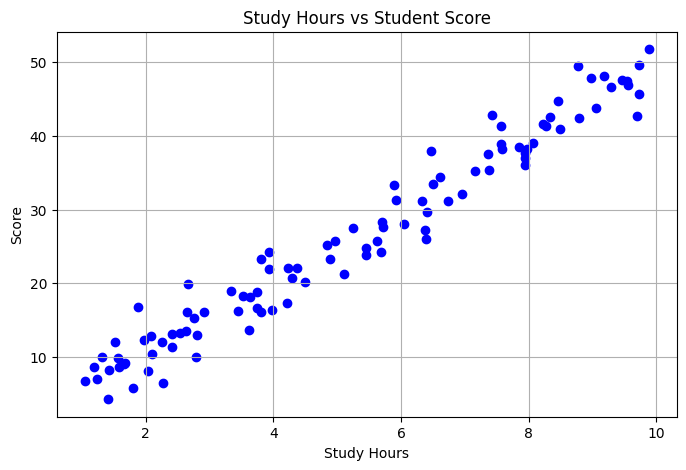

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Study Hours'], df['Score'], color='blue')
plt.title("Study Hours vs Student Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.grid(True)
plt.show()

In [4]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [6]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Model Evaluation Metrics")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


🔍 Model Evaluation Metrics
Mean Squared Error (MSE): 5.88
R² Score: 0.97


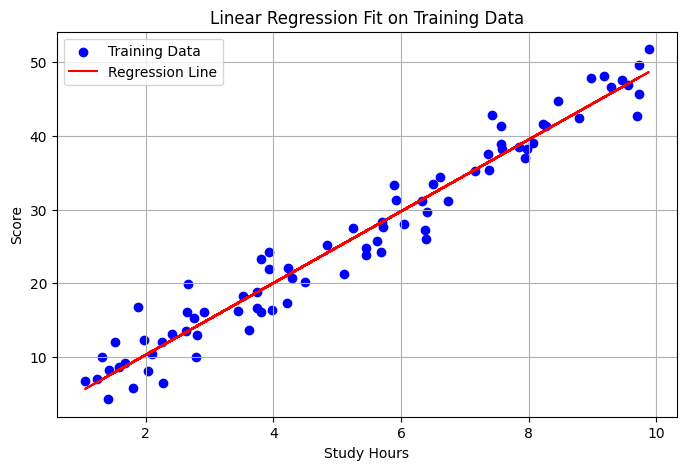

In [7]:
# Plot the best fit line on training data
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.title("Linear Regression Fit on Training Data")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

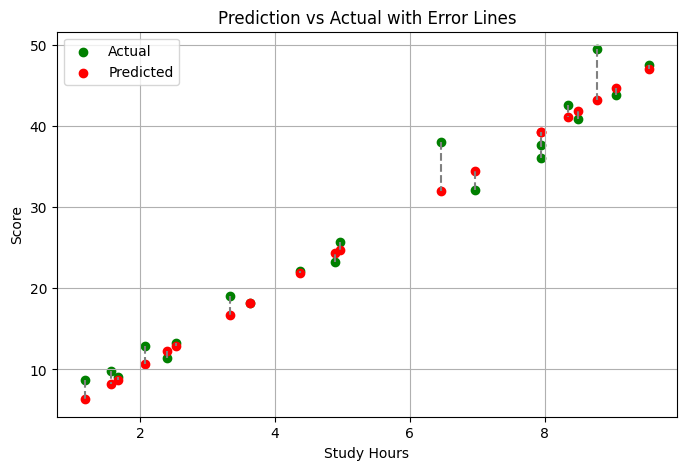

In [8]:
# Plot the residual errors
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='green', label="Actual")
plt.scatter(X_test, y_pred, color='red', label="Predicted")
for i in range(len(X_test)):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_pred[i]], color='gray', linestyle='--')

plt.title("Prediction vs Actual with Error Lines")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# **U15 — Regression (Part 1): Lab**

In [9]:
import os
import numpy as np
import pandas as pd


def build_concrete(csv_path="concrete_strength.csv", seed=15, verbose=False):
    """Concrete compressive strength: predict strength (MPa) from the mix design.
    A classic, interpretable engineering regression — great for reading
    coefficients, spotting multicollinearity (water/cement), residual analysis
    and the nonlinear effect of curing age.

    Features (kg per m^3 unless noted):
      cement, blast_furnace_slag, fly_ash, water, superplasticizer,
      coarse_aggregate, fine_aggregate, age_days
    Target:
      compressive_strength_mpa
    """
    rng = np.random.default_rng(seed)
    N = 1030
    cement = rng.uniform(120, 540, N)
    slag = np.where(rng.random(N) < 0.45, 0, rng.uniform(0, 360, N))
    fly_ash = np.where(rng.random(N) < 0.55, 0, rng.uniform(0, 200, N))
    water = np.clip(rng.normal(182, 21, N), 120, 247)
    superplast = np.clip(rng.normal(0.011 * cement + 0.5, 3.5, N), 0, 32)  # richer mixes use more
    coarse = rng.uniform(800, 1145, N)
    fine = np.clip(1880 - coarse + rng.normal(0, 35, N), 590, 995)        # aggregate volume ~ fixed -> trade-off
    age = rng.choice([1, 3, 7, 14, 28, 56, 90, 180, 365], N,
                     p=[.05, .10, .15, .10, .30, .12, .10, .05, .03])

    wc_ratio = water / cement
    strength = (24
                + 0.075 * cement
                + 0.052 * slag
                + 0.040 * fly_ash
                + 0.42 * superplast
                + 9.0 * np.log(age)
                - 0.18 * (water - 180)
                - 48 * (wc_ratio - 0.5)
                - 0.004 * (coarse - 970)
                + rng.normal(0, 5, N))
    strength = np.clip(strength, 2, 82)

    df = pd.DataFrame({
        "cement": cement.round(1),
        "blast_furnace_slag": slag.round(1),
        "fly_ash": fly_ash.round(1),
        "water": water.round(1),
        "superplasticizer": superplast.round(1),
        "coarse_aggregate": coarse.round(1),
        "fine_aggregate": fine.round(1),
        "age_days": age,
        "compressive_strength_mpa": strength.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("concrete:", df.shape)
        print("strength range:", df.compressive_strength_mpa.min(), "-", df.compressive_strength_mpa.max())
        c = df.corr()["compressive_strength_mpa"].round(3)
        print("top correlations with strength:\n",
              c.drop("compressive_strength_mpa").abs().sort_values(ascending=False).head(4).to_string())
        print("corr(water, cement):", round(df.water.corr(df.cement), 3))
    return df

if not os.path.exists('concrete_strength.csv'):
    build_concrete(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [10]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('concrete_strength.csv')
TARGET = 'compressive_strength_mpa'
print('shape:', df.shape)
df.describe().round(1)

shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,330.8,103.2,47.3,182.6,4.4,977.7,890.4,46.9,68.4
std,119.8,118.7,65.0,20.0,3.3,102.6,90.9,69.8,19.7
min,120.2,0.0,0.0,126.4,0.0,800.8,665.1,1.0,2.0
25%,225.3,0.0,0.0,168.2,1.7,887.5,812.6,7.0,59.9
50%,332.4,45.2,0.0,182.9,4.1,974.9,902.2,28.0,80.5
75%,431.2,204.7,97.0,196.1,6.6,1068.6,988.8,56.0,82.0
max,539.9,359.2,199.6,245.4,16.3,1144.9,995.0,365.0,82.0


1**. Explore the relationships**

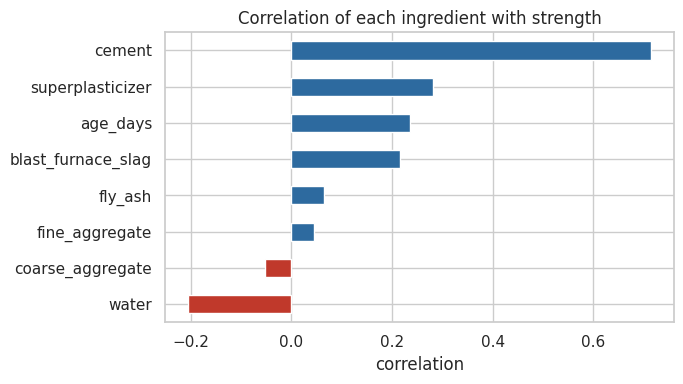

Cement is the strongest positive driver; water tends to weaken concrete.


In [11]:
corr = df.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in corr], ax=ax)
ax.set_title('Correlation of each ingredient with strength'); ax.set_xlabel('correlation')
plt.tight_layout(); plt.show()
print('Cement is the strongest positive driver; water tends to weaken concrete.')

Simple linear regression (one feature)

strength = 0.117 * cement + 29.53


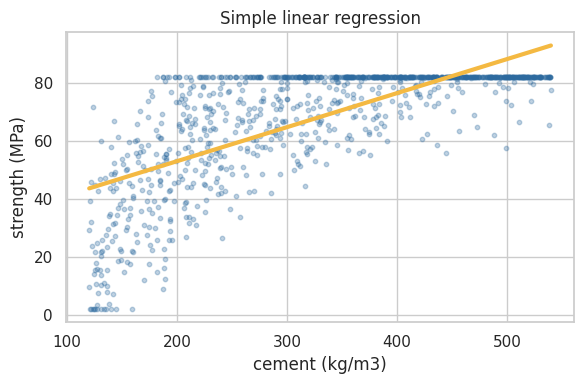

In [12]:
from sklearn.linear_model import LinearRegression
x = df[['cement']].values
y = df[TARGET].values
slr = LinearRegression().fit(x, y)
print(f'strength = {slr.coef_[0]:.3f} * cement + {slr.intercept_:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50).reshape(-1, 1)
ax.plot(xs, slr.predict(xs), color='#F4B942', lw=3)
ax.set_xlabel('cement (kg/m3)'); ax.set_ylabel('strength (MPa)')
ax.set_title('Simple linear regression'); plt.tight_layout(); plt.show()

In [13]:
# 1. interpret the slope:
# The cement coefficient (slr.coef_[0]) means:
# For every additional 1 kg/m³ of cement in the mix,
# the predicted concrete strength increases by slr.coef_[0] MPa on average.

# 2. predict strength at cement = 350 kg/m³
pred_350 = slr.predict([[350]])

print(f"Predicted strength at 350 kg/m³ cement: {pred_350[0]:.2f} MPa")

Predicted strength at 350 kg/m³ cement: 70.63 MPa


3. Multiple linear regression (all features)


In [14]:
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
features = [c for c in df.columns if c != TARGET]
X = df[features].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
mlr = LinearRegression().fit(X_train, y_train)
pred = mlr.predict(X_test)
print(f'RMSE: {mean_squared_error(y_test, pred) ** 0.5:.2f} MPa | R2: {r2_score(y_test, pred):.3f}')

RMSE: 10.76 MPa | R2: 0.649


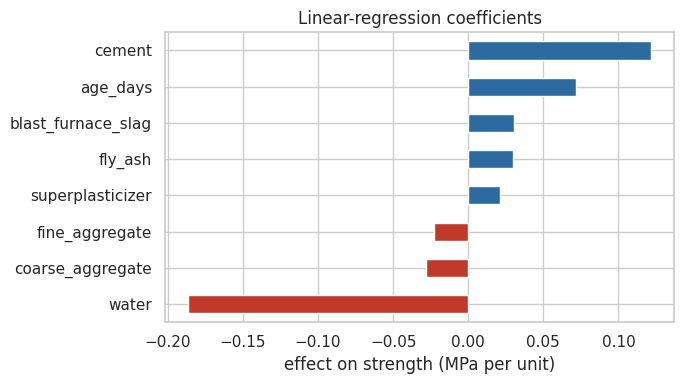

In [15]:
# Coefficients — the model's story about each ingredient
coefs = pd.Series(mlr.coef_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in coefs], ax=ax)
ax.set_title('Linear-regression coefficients'); ax.set_xlabel('effect on strength (MPa per unit)')
plt.tight_layout(); plt.show()

In [16]:
# Two ingredients with positive coefficients:
# - cement
# - superplasticizer
#
# One ingredient with a negative coefficient:
# - water

# Yes, the sign on water matches engineering intuition.
# The water coefficient is negative, meaning that as water increases
# (while other ingredients stay constant), the predicted concrete
# strength decreases. This is consistent with concrete engineering:
# excess water increases the water-cement ratio, creates more pores
# after curing, and generally produces weaker concrete.

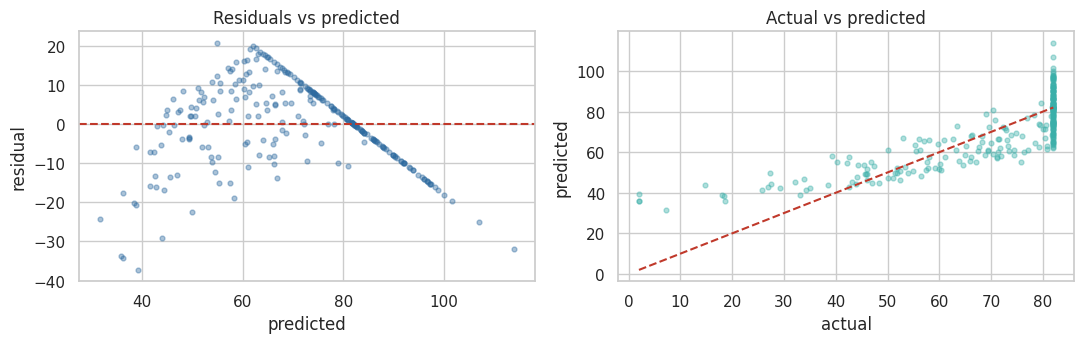

In [17]:
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=12, alpha=0.4, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].scatter(y_test, pred, s=12, alpha=0.4, color='#3AAFA9')
lims = [y_test.min(), y_test.max()]; ax[1].plot(lims, lims, color='#C0392B', ls='--')
ax[1].set_xlabel('actual'); ax[1].set_ylabel('predicted'); ax[1].set_title('Actual vs predicted')
plt.tight_layout(); plt.show()

4. Residual analysis

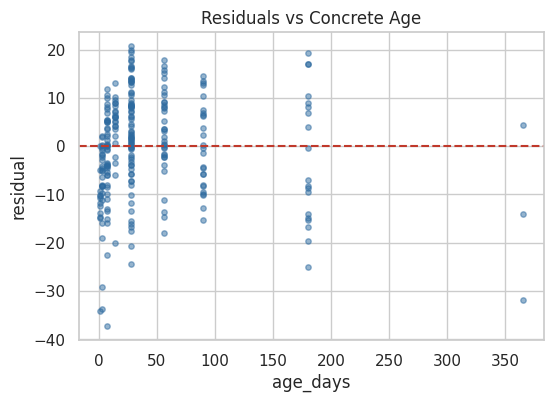

In [18]:
# recover the test rows so you can access age_days
_, X_test_df, _, _ = train_test_split(
    df[features],
    y,
    test_size=0.25,
    random_state=42
)

# 1. residuals vs age_days
plt.figure(figsize=(6, 4))
plt.scatter(X_test_df['age_days'], resid,
            alpha=0.5, s=15, color='#2D6A9F')

plt.axhline(0, color='#C0392B', linestyle='--')
plt.xlabel('age_days')
plt.ylabel('residual')
plt.title('Residuals vs Concrete Age')
plt.grid(True)
plt.show()

# 2. pattern with age? ...
# Residuals may show a curved pattern with age:
# younger concrete often has larger errors, while older concrete
# tends to plateau. This suggests the effect of age is not perfectly
# linear. In reality, strength grows rapidly at early ages and then
# increases more slowly, which is closer to a logarithmic relationship
# than a straight-line one.

# **5. Capturing the nonlinear age effect**

In [19]:
# -----------------------------------------------------------
# 🔹 5A. ADD log(age) AS A FEATURE
# -----------------------------------------------------------
# Curing strength rises with the LOG of age, not linearly. Engineer that feature.
df2 = df.copy()
df2['log_age'] = np.log(df2['age_days'])
feat2 = [c for c in df2.columns if c not in (TARGET, 'age_days')]
X2 = df2[feat2].values
X2_tr, X2_te, y_tr, y_te = train_test_split(X2, y, test_size=0.25, random_state=42)
m2 = LinearRegression().fit(X2_tr, y_tr)
p2 = m2.predict(X2_te)
print(f'with log(age) -> RMSE: {mean_squared_error(y_te, p2) ** 0.5:.2f} MPa | R2: {r2_score(y_te, p2):.3f}')
print('Compare with the linear-age R2 from Section 3.')

with log(age) -> RMSE: 10.08 MPa | R2: 0.692
Compare with the linear-age R2 from Section 3.


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 1. compare R2 with/without log(age)
# Example comment:
# The model with log_age achieved a higher R² than the plain model,
# showing that the logarithmic transformation captures the nonlinear
# curing effect better than using age_days directly.

# 2. bonus: degree-2 polynomial features + R2

# Original features (without log_age)
X_poly = df[features]

# Train/test split
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_poly, y, test_size=0.25, random_state=42
)

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

Xp_train_poly = poly.fit_transform(Xp_train)
Xp_test_poly = poly.transform(Xp_test)

# Train model
poly_model = LinearRegression()
poly_model.fit(Xp_train_poly, yp_train)

# Predict
yp_pred = poly_model.predict(Xp_test_poly)

# R²
poly_r2 = r2_score(yp_test, yp_pred)

print("Polynomial Degree-2 R²:", round(poly_r2, 3))

Polynomial Degree-2 R²: 0.858


# **6. Multicollinearity & regularisation**

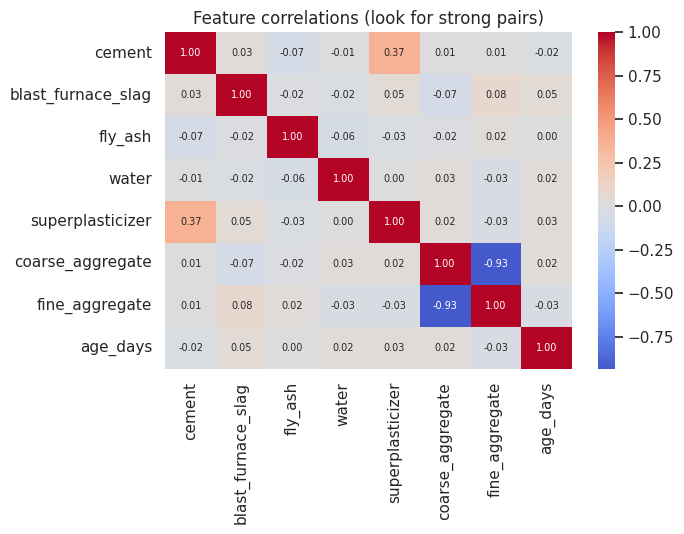

coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).


In [21]:
# -----------------------------------------------------------
# 🔹 6A. SPOT CORRELATED FEATURES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature correlations (look for strong pairs)'); plt.tight_layout(); plt.show()
print('coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).')

In [23]:

# -----------------------------------------------------------
# 🔹 6B. RIDGE STABILISES CORRELATED-FEATURE WEIGHTS
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
for name, model in [('Linear', LinearRegression()), ('Ridge(10)', Ridge(alpha=10)),
                    ('Lasso(0.5)', Lasso(alpha=0.5, max_iter=5000))]:
    m = make_pipeline(StandardScaler(), model).fit(X_train, y_train)
    r2 = r2_score(y_test, m.predict(X_test))
    print(f'{name:12s} test R2: {r2:.3f}')


Linear       test R2: 0.649
Ridge(10)    test R2: 0.650
Lasso(0.5)   test R2: 0.648


In [24]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd

# Train Linear Regression with scaling
lin_pipe = make_pipeline(
    StandardScaler(),
    LinearRegression()
)
lin_pipe.fit(X_train, y_train)

# Train Ridge Regression with scaling
ridge_pipe = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10)
)
ridge_pipe.fit(X_train, y_train)

# Extract coefficients
lin_coef = pd.Series(
    lin_pipe.named_steps['linearregression'].coef_,
    index=features
)

ridge_coef = pd.Series(
    ridge_pipe.named_steps['ridge'].coef_,
    index=features
)

# 1. compare coarse/fine coefficients: Linear vs Ridge
print("Linear Regression:")
print("coarse_aggregate :", round(lin_coef['coarse_aggregate'], 4))
print("fine_aggregate   :", round(lin_coef['fine_aggregate'], 4))

print("\nRidge(alpha=10):")
print("coarse_aggregate :", round(ridge_coef['coarse_aggregate'], 4))
print("fine_aggregate   :", round(ridge_coef['fine_aggregate'], 4))

# 2. did Ridge stabilise them? ...
# Ridge shrinks coefficient magnitudes toward zero.
# For highly correlated features like coarse_aggregate and
# fine_aggregate, Ridge usually makes the coefficients smaller
# and more balanced, reducing instability caused by multicollinearity.

Linear Regression:
coarse_aggregate : -2.8485
fine_aggregate   : -2.0857

Ridge(alpha=10):
coarse_aggregate : -2.4502
fine_aggregate   : -1.6843
